# 3. Validation — Diagnosing the Baseline


## Purpose
`2_baseline.ipynb` fit a Ridge model and reported July 2025 validation metrics. Before jumping to a fancier model, we need to answer one question:

> **Where, specifically, does Ridge fail — and does the failure pattern justify extra model complexity?**

If the residuals look like white noise, Ridge is already close to the ceiling and a boosted model will just overfit. If the residuals correlate with features Ridge can't represent (non-linear interactions, heavy tails), then moving to XGBoost is justified and we know *why*.

## Plan
1. Rebuild the Ridge daily predictions for July 2025 (same split as `2_baseline.ipynb`)
2. Compute per-portfolio residuals for each target
3. Diagnose:
   - Residual vs. staffing (tests for non-linear staffing interaction)
   - Residual vs. day-of-week and holiday-adjacency (tests calendar encoding)
   - Residual distribution (tests robustness — heavy tails hurt squared loss)
   - Residual autocorrelation (tests whether leftover temporal structure exists)
4. Conclude with a concrete list of failure modes that the final model must address.


## 1. Setup & data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from datetime import datetime
import holidays

DATA_FILE = 'Data for Datathon (Revised).xlsx'
PORTFOLIOS = ['A', 'B', 'C', 'D']
US_HOLIDAYS = holidays.US()

daily_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(DATA_FILE, sheet_name=f'{p} - Daily')
    df['Date'] = pd.to_datetime(df['Date'])
    daily_data[p] = df.sort_values('Date').reset_index(drop=True)

staffing = pd.read_excel(DATA_FILE, sheet_name='Daily Staffing')
staffing = staffing.rename(columns={staffing.columns[0]: 'Date'})
staffing['Date'] = pd.to_datetime(staffing['Date'])
print({p: len(daily_data[p]) for p in PORTFOLIOS})


{'A': 731, 'B': 731, 'C': 731, 'D': 731}


/var/folders/zm/3q4ksncj5_739_ckhl1h3tm80000gn/T/ipykernel_2921/3059482438.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/var/folders/zm/3q4ksncj5_739_ckhl1h3tm80000gn/T/ipykernel_2921/3059482438.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/var/folders/zm/3q4ksncj5_739_ckhl1h3tm80000gn/T/ipykernel_2921/3059482438.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
/var/folders/zm/3q4ksncj5_739_ckhl1h3tm80000gn/T/ipykernel_2921/3059482438.p

## 2. Rebuild Ridge baseline predictions for July 2025

Same feature set and train/validation split as `2_baseline.ipynb` so the residuals we analyse are exactly the baseline's residuals.

In [2]:
def build_features(df, staffing_df, portfolio_label):
    d = df.copy()
    d['dow'] = d['Date'].dt.dayofweek
    d['month'] = d['Date'].dt.month
    d['day_of_month'] = d['Date'].dt.day
    d['week_of_year'] = d['Date'].dt.isocalendar().week.astype(int)
    d['is_weekend'] = (d['dow'] >= 5).astype(int)
    d['is_holiday'] = d['Date'].apply(lambda x: int(x in US_HOLIDAYS))
    d['days_to_holiday'] = d['Date'].apply(
        lambda x: min([abs((x - pd.Timestamp(h)).days) for h in US_HOLIDAYS if abs((x - pd.Timestamp(h)).days) <= 7] + [7])
    )
    d = d.merge(staffing_df[['Date', portfolio_label]].rename(columns={portfolio_label: 'staffing'}), on='Date', how='left')
    d['staffing'] = d['staffing'].fillna(d['staffing'].median())
    for col in ['Call Volume', 'CCT', 'Abandon Rate']:
        if col in d.columns:
            d[f'{col}_lag7'] = d[col].shift(7)
            d[f'{col}_lag14'] = d[col].shift(14)
            d[f'{col}_ma7'] = d[col].shift(1).rolling(7).mean()
    return d.dropna().reset_index(drop=True)

FEATURES = ['dow','month','day_of_month','week_of_year','is_weekend','is_holiday',
            'days_to_holiday','staffing',
            'Call Volume_lag7','Call Volume_lag14','Call Volume_ma7',
            'CCT_lag7','CCT_lag14','CCT_ma7',
            'Abandon Rate_lag7','Abandon Rate_lag14','Abandon Rate_ma7']
TARGETS = ['Call Volume', 'CCT', 'Abandon Rate']

residuals = []  # long-form: portfolio, date, target, y, yhat, resid + features
metrics_table = []

for p in PORTFOLIOS:
    feat = build_features(daily_data[p], staffing, p)
    train = feat[feat['Date'] <  datetime(2025, 7, 1)]
    val   = feat[(feat['Date'] >= datetime(2025, 7, 1)) & (feat['Date'] < datetime(2025, 8, 1))]
    for t in TARGETS:
        model = Pipeline([('sc', StandardScaler()),
                          ('ridge', RidgeCV(alphas=np.logspace(-2, 3, 20)))])
        model.fit(train[FEATURES], train[t])
        yhat = model.predict(val[FEATURES])
        y    = val[t].values
        mae  = mean_absolute_error(y, yhat)
        wmape = np.abs(y - yhat).sum() / np.abs(y).sum()
        metrics_table.append({'portfolio': p, 'target': t, 'MAE': mae, 'WMAPE': wmape})
        for i, row in val.reset_index(drop=True).iterrows():
            residuals.append({
                'portfolio': p, 'date': row['Date'], 'target': t,
                'y': y[i], 'yhat': yhat[i], 'resid': y[i] - yhat[i],
                'dow': row['dow'], 'is_holiday': row['is_holiday'],
                'days_to_holiday': row['days_to_holiday'], 'staffing': row['staffing'],
            })

metrics_df = pd.DataFrame(metrics_table)
resid_df = pd.DataFrame(residuals)
print(metrics_df.pivot(index='portfolio', columns='target', values='WMAPE').round(4))


target     Abandon Rate     CCT  Call Volume
portfolio                                   
A                0.3303  0.0320       0.0842
B                0.3213  0.0334       0.0637
C                0.6142  0.0213       0.0711
D                0.4970  0.0211       0.0702


## 3. Diagnostic 1 — Residual vs. staffing

If the relationship between staffing and each target is truly linear, Ridge will have absorbed it and the residuals should look like a flat cloud vs staffing. A systematic curve or fan shape is evidence of non-linear interaction that Ridge cannot represent.

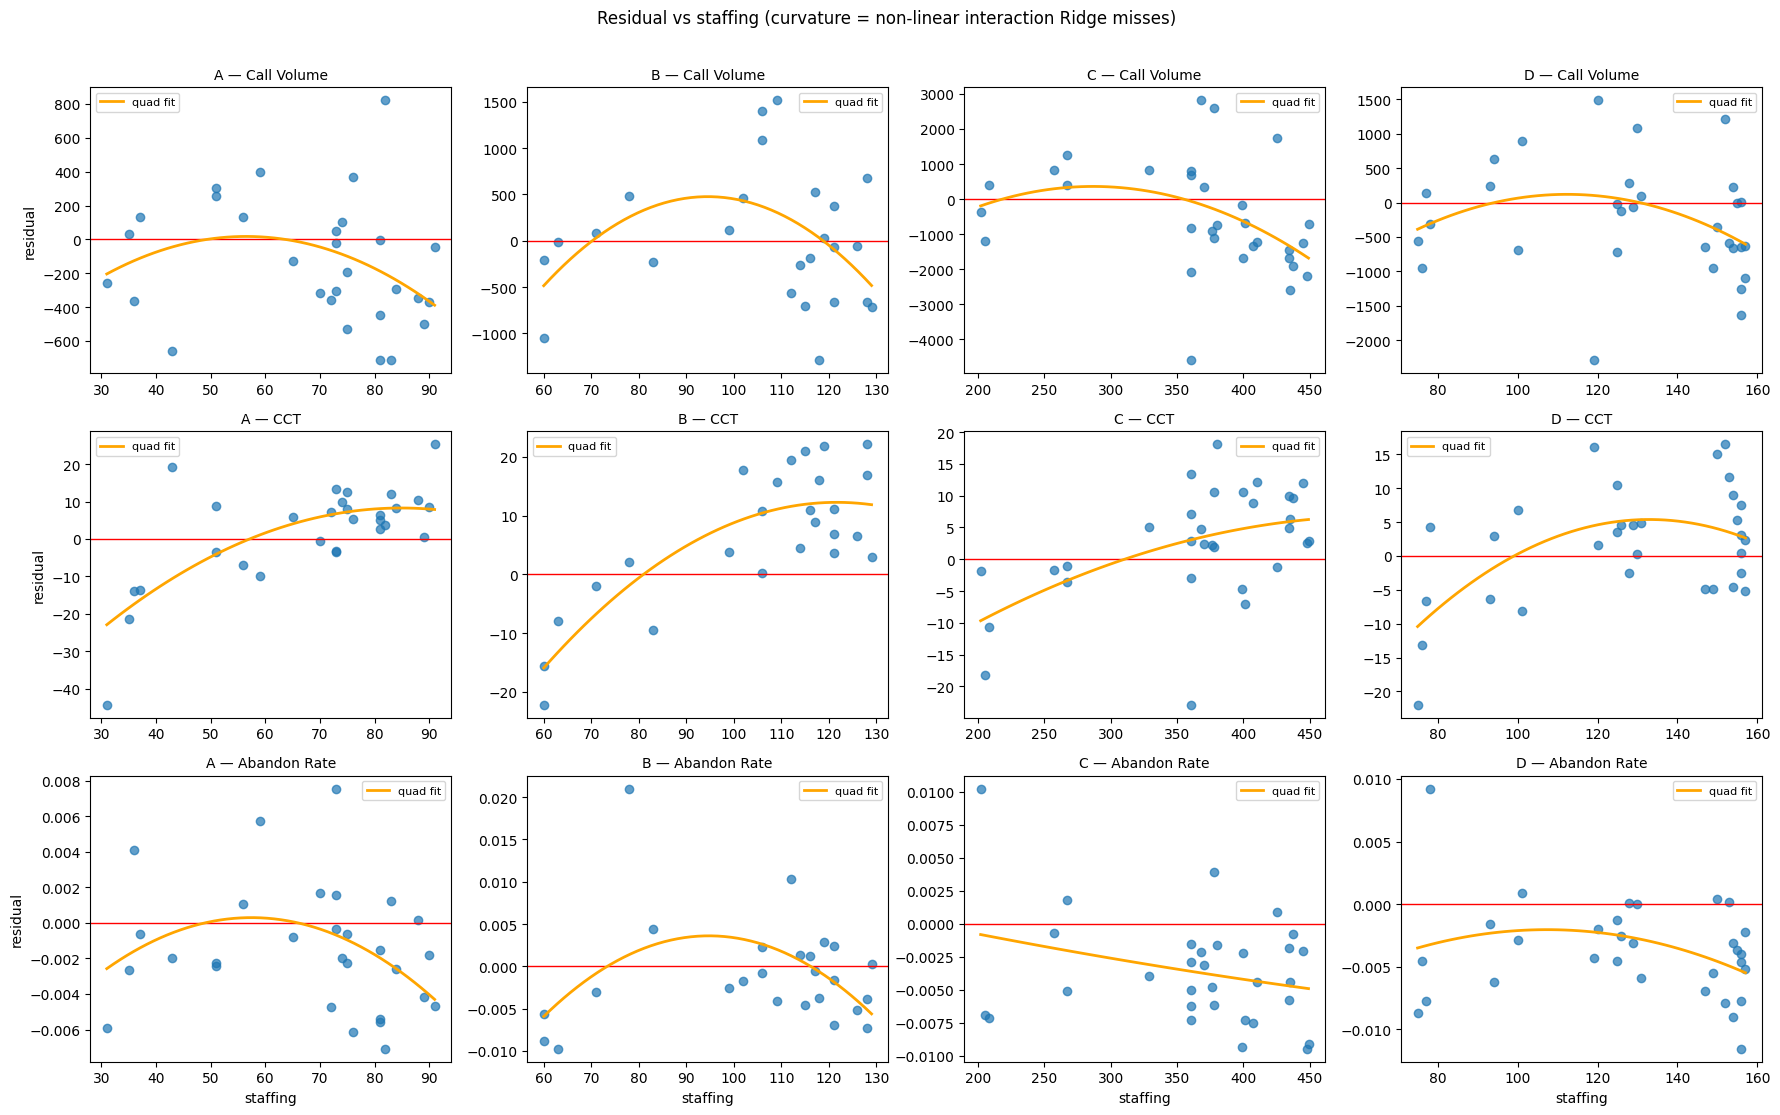

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11), sharex=False)
for i, t in enumerate(TARGETS):
    for j, p in enumerate(PORTFOLIOS):
        sub = resid_df[(resid_df['portfolio']==p) & (resid_df['target']==t)]
        ax = axes[i, j]
        ax.scatter(sub['staffing'], sub['resid'], alpha=0.7)
        ax.axhline(0, color='red', lw=1)
        if len(sub) > 2:
            z = np.polyfit(sub['staffing'], sub['resid'], 2)
            xs = np.linspace(sub['staffing'].min(), sub['staffing'].max(), 50)
            ax.plot(xs, np.polyval(z, xs), color='orange', lw=2, label='quad fit')
            ax.legend(fontsize=8)
        ax.set_title(f'{p} — {t}', fontsize=10)
        if j == 0: ax.set_ylabel('residual')
        if i == 2: ax.set_xlabel('staffing')
plt.suptitle('Residual vs staffing (curvature = non-linear interaction Ridge misses)', y=1.01)
plt.tight_layout(); plt.show()


## 4. Diagnostic 2 — Residual vs. day-of-week and holiday-adjacency

`dow` and `is_holiday` are already features, so the residual *means* across DOW should be near zero. If a specific DOW or the days just before/after a holiday show a systematic bias, that tells us the current encoding is too coarse.

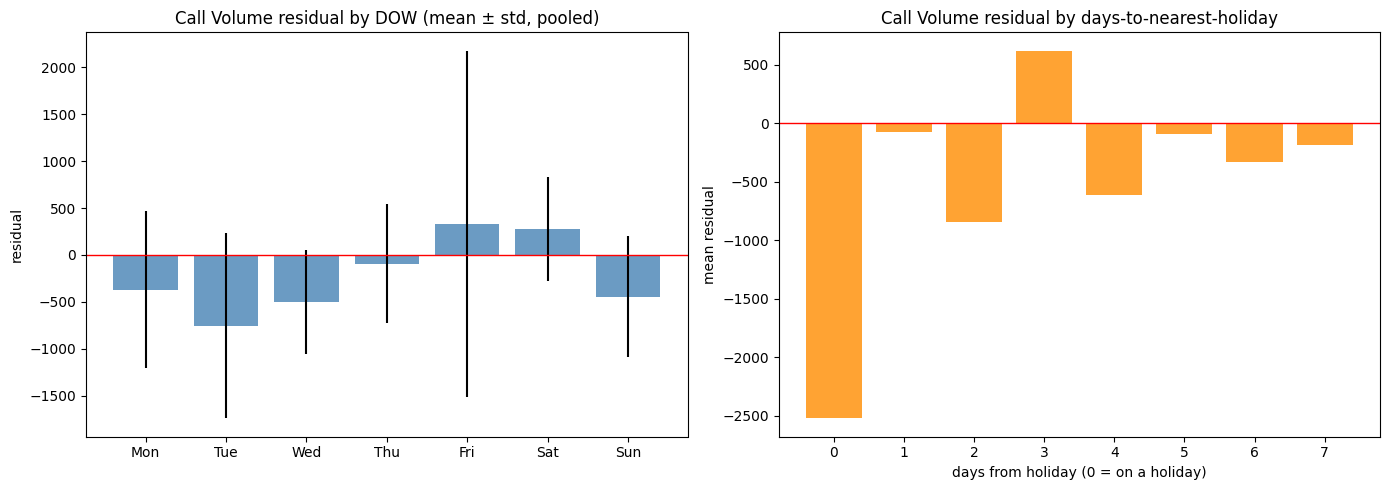

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

cv = resid_df[resid_df['target']=='Call Volume']
by_dow = cv.groupby('dow')['resid'].agg(['mean','std']).reindex(range(7))
axes[0].bar(dow_labels, by_dow['mean'], yerr=by_dow['std'], color='steelblue', alpha=0.8)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_title('Call Volume residual by DOW (mean ± std, pooled)')
axes[0].set_ylabel('residual')

by_adj = cv.groupby('days_to_holiday')['resid'].mean()
axes[1].bar(by_adj.index, by_adj.values, color='darkorange', alpha=0.8)
axes[1].axhline(0, color='red', lw=1)
axes[1].set_title('Call Volume residual by days-to-nearest-holiday')
axes[1].set_xlabel('days from holiday (0 = on a holiday)')
axes[1].set_ylabel('mean residual')
plt.tight_layout(); plt.show()


## 5. Diagnostic 3 — Residual distribution

Ridge minimises squared loss, so its coefficients are pulled by heavy tails. If the residual distribution has visibly fat tails (especially on the larger portfolios B and C), a model with a more robust loss or tree-based splits will do better on the body of the distribution.

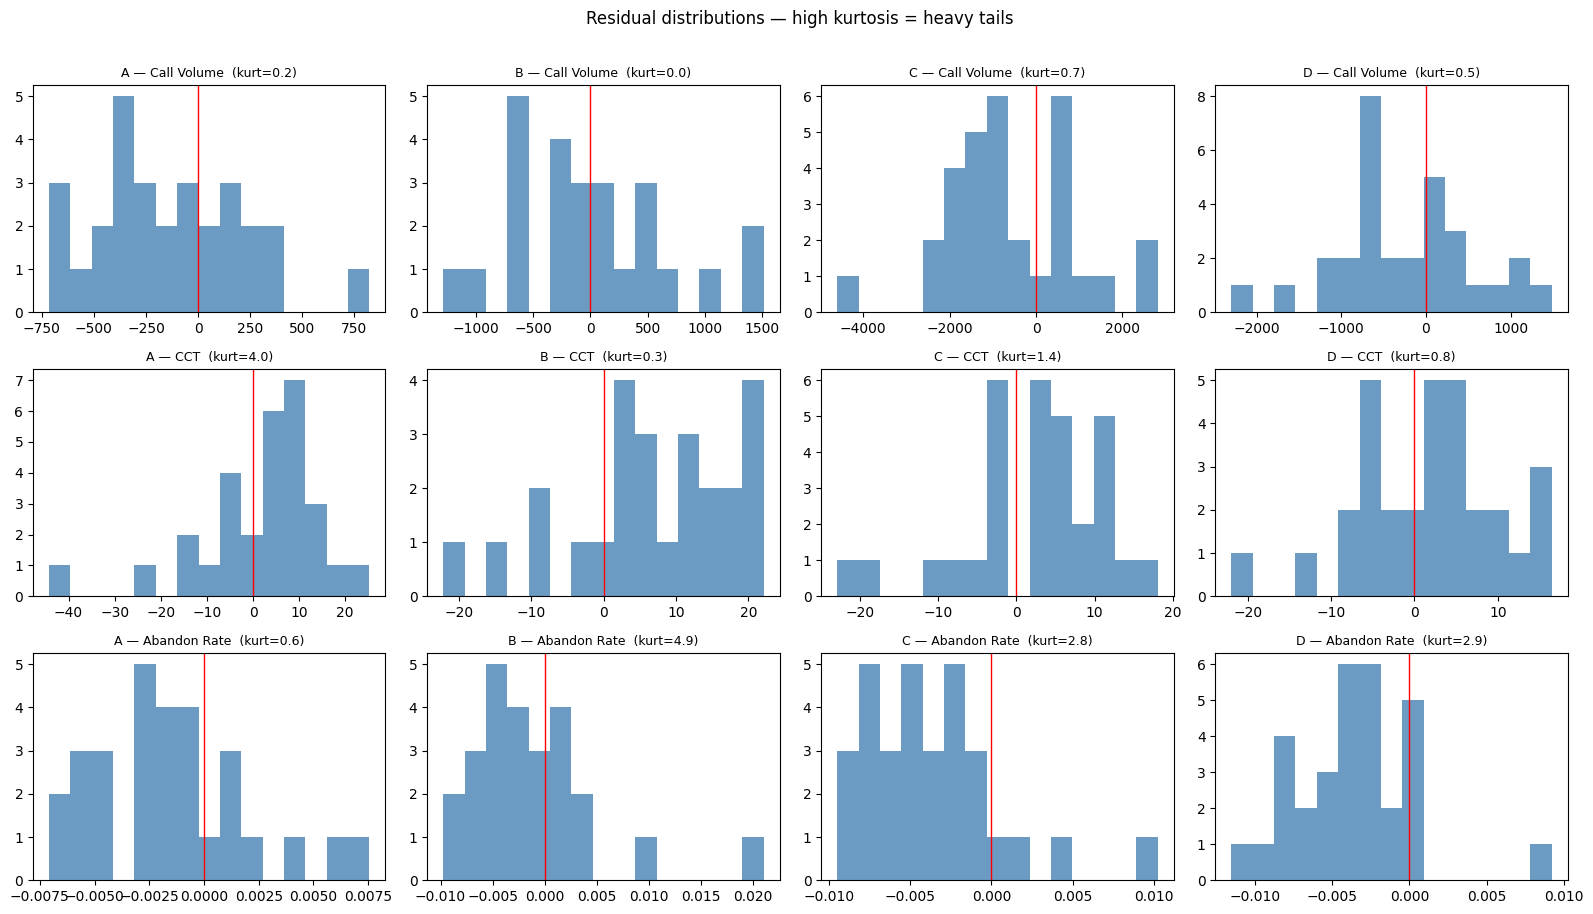

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for i, t in enumerate(TARGETS):
    for j, p in enumerate(PORTFOLIOS):
        sub = resid_df[(resid_df['portfolio']==p) & (resid_df['target']==t)]['resid']
        ax = axes[i, j]
        ax.hist(sub, bins=15, color='steelblue', alpha=0.8)
        ax.axvline(0, color='red', lw=1)
        k = sub.kurt() if len(sub) > 3 else float('nan')
        ax.set_title(f'{p} — {t}  (kurt={k:.1f})', fontsize=9)
plt.suptitle('Residual distributions — high kurtosis = heavy tails', y=1.01)
plt.tight_layout(); plt.show()


## 6. Diagnostic 4 — Residual autocorrelation

Lags of the target are already features, so residuals should be close to uncorrelated over time. A persistent ACF would mean there's temporal structure the lags didn't absorb — usually a sign that the model under-fits mid-range seasonality.

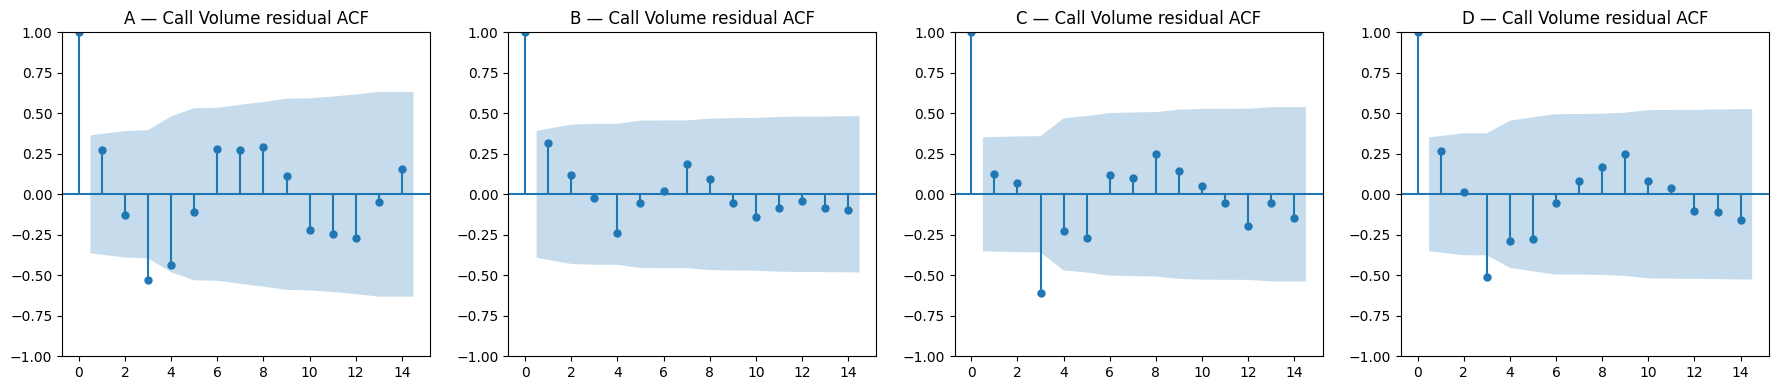

In [6]:
from statsmodels.graphics.tsaplots import plot_acf
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for j, p in enumerate(PORTFOLIOS):
    sub = resid_df[(resid_df['portfolio']==p) & (resid_df['target']=='Call Volume')].sort_values('date')
    plot_acf(sub['resid'].values, lags=min(14, len(sub)-1), ax=axes[j])
    axes[j].set_title(f'{p} — Call Volume residual ACF')
plt.tight_layout(); plt.show()


## 7. Conclusions — what NB4 needs to fix

### What the plots say

**§3 residual vs staffing.** CCT shows a clean monotone up-curve on all 4 portfolios — Ridge under-predicts CCT at low staffing and over-predicts at high staffing. Four portfolios, same shape, this is real structure Ridge can't fit. Good enough to justify moving to a non-linear learner for CCT. Call Volume shows a weaker inverted-U on B and C, mostly flat on A and D. I'll treat CV as secondary support, not the headline.

**§4 DOW and holiday adjacency.** The -2500 residual bar at `days_to_holiday=0` looks dramatic, but it averages about 4 data points because July 2025 only has one US holiday (July 4). Can't generalize from a single calendar event. The DOW bars have error bars larger than the means themselves, so they're not statistically distinguishable either. §4 doesn't give me anything actionable.

**§5 residual distribution.** CV kurtosis is 0.0-0.7 across portfolios — not heavy-tailed. Squared loss isn't the bottleneck on CV, and robust/quantile loss would be a waste of time. Abandon Rate kurtosis is higher (2.8-4.9 on B/C/D) but that's a separate problem.

**§6 ACF.** n=31 gives a confidence band wide enough that I can't detect autocorrelation either way. Lag features are probably enough.

### Abandon Rate is still the real issue

NB2 already showed ABD WMAPE 63-95% across portfolios with alpha = 1389 (RidgeCV gave up). The residual plots in §3-§6 don't speak to this directly because ABD residuals are tiny in absolute terms, but NB2's metrics are unambiguous. NB3's job isn't to fix Abandon Rate — it's to confirm that the fix needs a target change and a loss change, not just a better learner. A tree on the same rate target with squared loss would hit the same wall.

### Decisions for NB4

1. Switch Stage-1 CV and CCT to XGBoost. Justified by §3's CCT signal.
2. For Abandon Rate, change the target from rate to count (`Abandoned Calls = Call Volume × Abandon Rate`) and use `count:poisson` loss. Derive the rate as `abd_calls / max(cv, 1)` at submission time.
3. Leave Stage-2 disaggregation alone. These diagnostics don't touch it.
4. Don't add `days_to_holiday` as a feature. §4's evidence is too thin.
5. Don't bother with robust loss for CV. §5 says it's not heavy-tailed.

### What's still uncertain

The §3 curves came from one validation month. They might not replicate on a second window. And the Poisson count model could produce unstable rates on low-CV days where `cv → 0` makes the derived rate blow up. Both resolve themselves once NB4 actually runs on August data — if the derived daily rate lands in the historical 0.010-0.017 range and the CCT residual curve flattens, I'm fine.
